In [10]:
import cv2
import mediapipe as mp
import numpy as np
import math
import os
import glob
from google.colab.patches import cv2_imshow

# Initialize MediaPipe Pose
mp_pose = mp.solutions.pose
pose = mp_pose.Pose(static_image_mode=True, min_detection_confidence=0.5)

In [ ]:
def calculate_angle(v1, v2):
    """Calculates the angle in degrees between two 2D vectors."""
    dot_product = np.dot(v1, v2)
    mag_v1 = np.linalg.norm(v1)
    mag_v2 = np.linalg.norm(v2)

    if mag_v1 == 0 or mag_v2 == 0:
        return 0.0

    # Clipping
    cos_theta = np.clip(dot_product / (mag_v1 * mag_v2), -1.0, 1.0)

    return math.degrees(math.acos(cos_theta))

In [ ]:
def analyze_cervical_posture_robust(image_path):

    image = cv2.imread(image_path)
    if image is None:
        print(f"Error: Could not load {image_path}.")
        return

    display_image = image.copy()

    # Convert BGR image to RGB for MediaPipe processing
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    height, width, _ = image.shape
    results = pose.process(image_rgb)

    if not results.pose_landmarks:
        print("Error: No pose detected in the image.")
        # Display image even if no pose is detected
        cv2.putText(display_image, "No Pose Detected", (50, 50), cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 0, 255), 2)
        cv2_imshow(display_image)
        print(f"\n Analysis Report for: {image_path} ")
        print("DIAGNOSIS: No Pose Detected")
        print("-" * 55)
        return

    landmarks = results.pose_landmarks.landmark

    # Helper to get pixel coordinates and visibility score
    def get_lm(landmark_enum):
        lm = landmarks[landmark_enum.value]
        return np.array([lm.x * width, lm.y * height]), lm.visibility

    # Extract required landmarks
    nose, nose_vis = get_lm(mp_pose.PoseLandmark.NOSE)
    l_ear, l_ear_vis = get_lm(mp_pose.PoseLandmark.LEFT_EAR)
    r_ear, r_ear_vis = get_lm(mp_pose.PoseLandmark.RIGHT_EAR)
    l_shldr, l_shldr_vis = get_lm(mp_pose.PoseLandmark.LEFT_SHOULDER)
    r_shldr, r_shldr_vis = get_lm(mp_pose.PoseLandmark.RIGHT_SHOULDER)

    diagnosis_messages = []
    is_normal = True

    # Draw landmarks for visualization
    mp.solutions.drawing_utils.draw_landmarks(
        display_image, results.pose_landmarks, mp_pose.POSE_CONNECTIONS,
        mp.solutions.drawing_styles.get_default_pose_landmarks_style())

    # Determine View (Frontal vs Profile)
    is_profile = False
    visible_side = None

    if l_ear_vis < 0.3 and r_ear_vis > 0.5:
        is_profile = True
        visible_side = 'Right'
    elif r_ear_vis < 0.3 and l_ear_vis > 0.5:
        is_profile = True
        visible_side = 'Left'

    # Apply Appropriate Features based on View

    if not is_profile:
        view_type = "FRONTAL (Checking for Laterocollis / Rotational Torticollis)"

        # Tilt Angle
        vector_head = l_ear - r_ear
        vector_torso = l_shldr - r_shldr
        tilt_angle = calculate_angle(vector_head, vector_torso)
        if tilt_angle > 90:
            tilt_angle = 180 - tilt_angle

        # Yaw Ratio
        dist_left = np.linalg.norm(nose - l_ear)
        dist_right = np.linalg.norm(nose - r_ear)
        yaw_ratio = max(dist_left, dist_right) / (min(dist_left, dist_right) + 1e-6)

        if tilt_angle > 15.0:
            diagnosis_messages.append("Laterocollis Detected (Lateral head tilt)")
            is_normal = False
        if yaw_ratio > 1.8:
            diagnosis_messages.append("Rotational Torticollis Detected (Head rotation)")
            is_normal = False

    else:
        view_type = f"PROFILE [{visible_side} Side Visible] (Checking for Antero/Retrocollis)"

        # Select the visible landmarks for the active side
        ear = l_ear if visible_side == 'Left' else r_ear
        shoulder = l_shldr if visible_side == 'Left' else r_shldr

        # Profile Plumb Line
        dx = ear[0] - shoulder[0]
        dy = abs(ear[1] - shoulder[1]) + 1e-6
        pitch_ratio = dx / dy

        # Logic to determine forward vs backward tilt depends on which way they are facing
        facing_left = nose[0] < ear[0] # Assuming nose is generally in front of ear in profile

        if facing_left:
            if pitch_ratio < -0.3:
                diagnosis_messages.append("Anterocollis Detected (Head tilted forward)")
                is_normal = False
            elif pitch_ratio > 0.3:
                diagnosis_messages.append("Retrocollis Detected (Head tilted backward)")
                is_normal = False
        else:
            if pitch_ratio > 0.3:
                diagnosis_messages.append("Anterocollis Detected (Head tilted forward)")
                is_normal = False
            elif pitch_ratio < -0.3:
                diagnosis_messages.append("Retrocollis Detected (Head tilted backward)")
                is_normal = False

    if is_normal:
        diagnosis_messages.append("Normal Head Posture Detected")

    display_text = f"File: {os.path.basename(image_path)}"
    cv2.putText(display_image, display_text, (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (255, 255, 255), 2)

    y_offset = 60
    for msg in diagnosis_messages:
        cv2.putText(display_image, f"DIAGNOSIS: {msg}", (10, y_offset), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 0) if "Normal" in msg else (0, 0, 255), 2)
        y_offset += 30

    cv2_imshow(display_image)

    print(f"\n Analysis Report for: {image_path}")
    print(f"View Detected: {view_type}")

    if not is_profile:
        print(f"Feature A (Tilt Angle) : {tilt_angle:.2f} degrees")
        print(f"Feature B (Yaw Ratio)  : {yaw_ratio:.2f}")
    else:
        print(f"Feature C (Pitch Ratio): {pitch_ratio:.2f}")

    for msg in diagnosis_messages:
        print(f"{msg}")
    print("-" * 55)

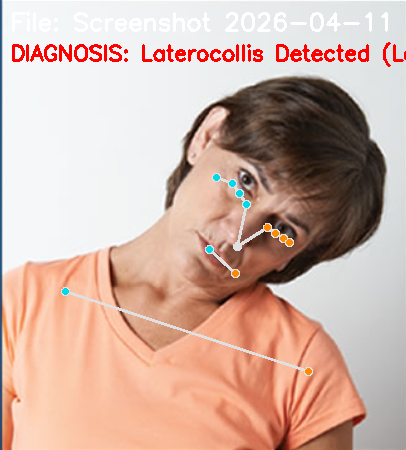


 Analysis Report for: /content/Screenshot 2026-04-11 225524.png
View Detected: FRONTAL (Checking for Laterocollis / Rotational Torticollis)
Feature A (Tilt Angle) : 23.89 degrees
Feature B (Yaw Ratio)  : 1.39
Laterocollis Detected (Lateral head tilt)
-------------------------------------------------------


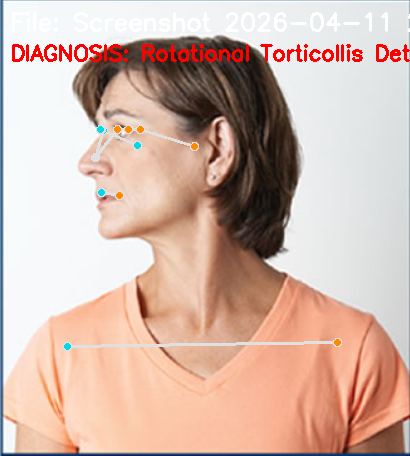


 Analysis Report for: /content/Screenshot 2026-04-11 225534.png
View Detected: FRONTAL (Checking for Laterocollis / Rotational Torticollis)
Feature A (Tilt Angle) : 2.23 degrees
Feature B (Yaw Ratio)  : 2.26
Rotational Torticollis Detected (Head rotation)
-------------------------------------------------------


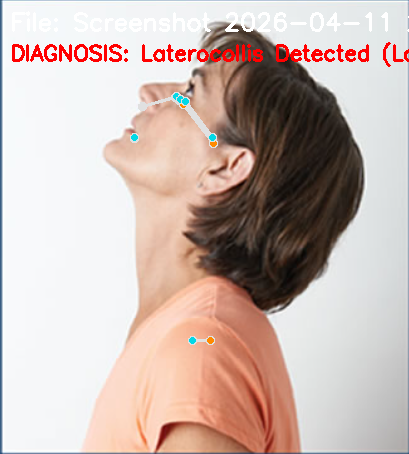


 Analysis Report for: /content/Screenshot 2026-04-11 225544.png
View Detected: FRONTAL (Checking for Laterocollis / Rotational Torticollis)
Feature A (Tilt Angle) : 80.06 degrees
Feature B (Yaw Ratio)  : 1.04
Laterocollis Detected (Lateral head tilt)
-------------------------------------------------------


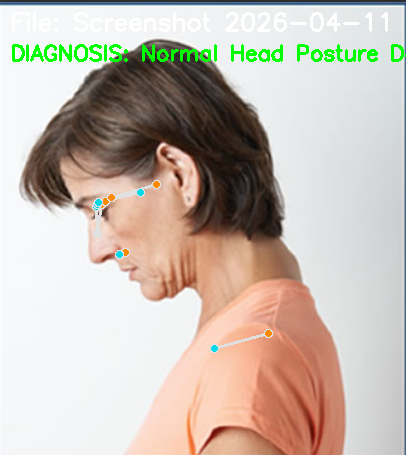


 Analysis Report for: /content/Screenshot 2026-04-11 225551.png
View Detected: FRONTAL (Checking for Laterocollis / Rotational Torticollis)
Feature A (Tilt Angle) : 8.02 degrees
Feature B (Yaw Ratio)  : 1.29
Normal Head Posture Detected
-------------------------------------------------------


In [17]:
folder_path = '/content/'

image_files = []
for ext in ('*.jpg', '*.jpeg', '*.png'):
    image_files.extend(glob.glob(os.path.join(folder_path, ext)))

for img_path in sorted(image_files):
    analyze_cervical_posture_robust(img_path)